# SVM (one-vs-all, lineaire)

Plan :
1. Cas logiques : OR, AND (lineairement separables), XOR, XNOR (non separables)
2. Frontiere de decision : OR vs XOR
3. Cas non lineaire (cercle) -- kernel trick
4. Cas d'images -- dataset chat/chien/autre
5. Sauvegarde et chargement du modele


In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from svm import lib, entrainer_svm, predire_svm, precision_svm


def dessiner_frontiere(model, X, labels, titre):
    """Affiche la frontiere de decision du modele sur des points 2D"""
    X = np.array(X, dtype=float)
    pas = 0.05
    valeurs_x = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    valeurs_y = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)

    Z = [[predire_svm(model, [x, y]) for x in valeurs_x] for y in valeurs_y]

    plt.contourf(valeurs_x, valeurs_y, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", edgecolors="k", s=80)
    plt.title(titre)
    plt.show()

## 1. Cas logiques

In [2]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
portes = {"OR": [0, 1, 1, 1], "AND": [0, 0, 0, 1], "XOR": [0, 1, 1, 0], "XNOR": [1, 0, 0, 1]}

for nom, labels in portes.items():
    model = entrainer_svm(inputs, labels, nb_classes=2)
    preds = [predire_svm(model, x) for x in inputs]
    lib.destroy_svm_model(model)
    print(f"{nom:5s} attendu={labels}  predit={preds}")

OR    attendu=[0, 1, 1, 1]  predit=[0, 1, 1, 1]
AND   attendu=[0, 0, 0, 1]  predit=[0, 0, 0, 1]
XOR   attendu=[0, 1, 1, 0]  predit=[0, 0, 0, 0]
XNOR  attendu=[1, 0, 0, 1]  predit=[1, 1, 1, 1]


## 2. Frontiere de decision : OR vs XOR

Le SVM ici est **lineaire** (produit scalaire simple, pas de noyau) : il ne peut
tracer qu'une droite. OR est lineairement separable, XOR ne l'est pas

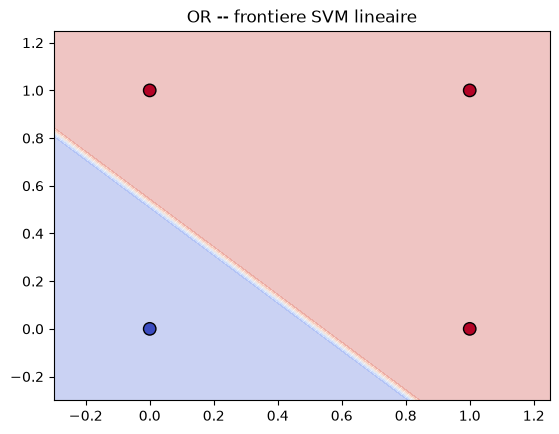

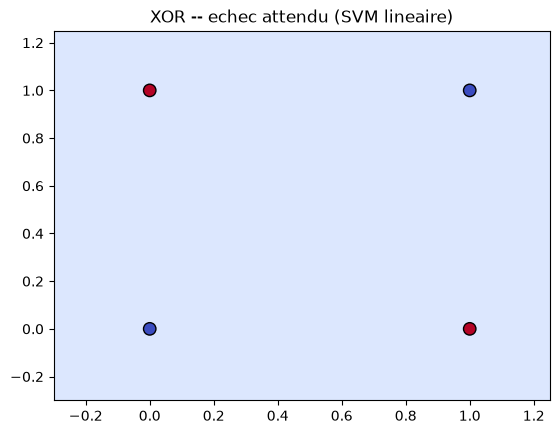

In [3]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]

labels_or = [0, 1, 1, 1]
model_or = entrainer_svm(inputs, labels_or, nb_classes=2)
dessiner_frontiere(model_or, inputs, labels_or, "OR -- frontiere SVM lineaire")
lib.destroy_svm_model(model_or)

labels_xor = [0, 1, 1, 0]
model_xor = entrainer_svm(inputs, labels_xor, nb_classes=2)
dessiner_frontiere(model_xor, inputs, labels_xor, "XOR -- echec attendu (SVM lineaire)")
lib.destroy_svm_model(model_xor)

## 3. Cas non lineaire (cercle) - kernel trick

Le SVM lineaire echoue par
construction. Le noyau RBF (kernel trick) projette implicitement les points
dans un espace ou ils deviennent separables -> la frontiere redevient une
courbe fermee dans l'espace d'origine.

Precision SVM lineaire (cercle) : 50.0 %


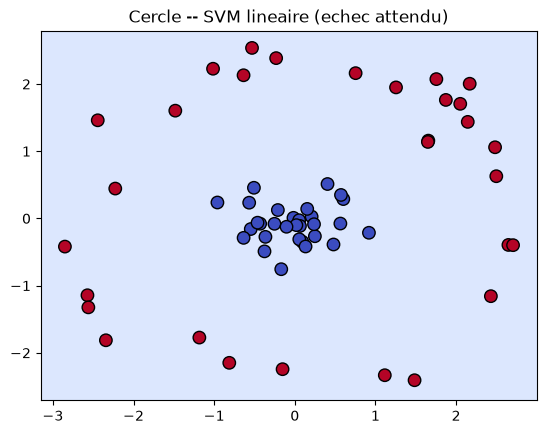

Precision SVM kernel RBF (cercle) : 100.0 %


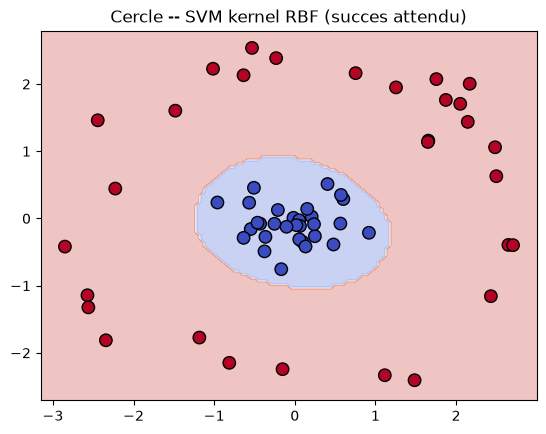

In [4]:
np.random.seed(0)
n = 30

angles_in = np.random.uniform(0, 2*np.pi, n)
rayons_in = np.random.uniform(0, 1.0, n)
points_in = np.column_stack([rayons_in*np.cos(angles_in), rayons_in*np.sin(angles_in)])

angles_out = np.random.uniform(0, 2*np.pi, n)
rayons_out = np.random.uniform(2.0, 3.0, n)
points_out = np.column_stack([rayons_out*np.cos(angles_out), rayons_out*np.sin(angles_out)])

X_cercle = np.vstack([points_in, points_out]).tolist()
y_cercle = [0]*n + [1]*n

model_lin = entrainer_svm(X_cercle, y_cercle, nb_classes=2, kernel="lineaire")
print("Precision SVM lineaire (cercle) :", precision_svm(model_lin, X_cercle, y_cercle), "%")
dessiner_frontiere(model_lin, X_cercle, y_cercle, "Cercle -- SVM lineaire (echec attendu)")
lib.destroy_svm_model(model_lin)

model_rbf = entrainer_svm(X_cercle, y_cercle, nb_classes=2, kernel="rbf", gamma=0.5)
print("Precision SVM kernel RBF (cercle) :", precision_svm(model_rbf, X_cercle, y_cercle), "%")
dessiner_frontiere(model_rbf, X_cercle, y_cercle, "Cercle -- SVM kernel RBF (succes attendu)")
lib.destroy_svm_model(model_rbf)

## Cas d'images -- dataset chat/chien/autre

Entrainement SVM lineaire (one-vs-all) sur le dataset reel.
On limite a **150 images par classe** pour eviter le crash memoire
(la matrice noyau croit en O(n²)).
Images 32x32 niveaux de gris, normalisees dans [-0.5, 0.5].

> **Note :** le SVM lineaire obtient ~33% (classe aleatoire) sur ce dataset.
> En 1024 dimensions avec peu d'exemples, l'optimisation de la DLL ne converge pas.
> C'est une limite connue du SVM lineaire strict sur des donnees haute dimension
> non lineairement separables -- le kernel trick (RBF) serait necessaire.

In [ ]:
from functions import load_dataset

MAX_PAR_CLASSE = 150
DATASET_DIR = os.path.abspath(os.path.join("..", "dataset"))

X_train_full, y_train_full = load_dataset(os.path.join(DATASET_DIR, "train_dataset"))
X_test_full,  y_test_full  = load_dataset(os.path.join(DATASET_DIR, "test_dataset"))

# On limite a MAX_PAR_CLASSE images par classe (0=chats, 1=chiens, 2=autres)
def limiter(X, Y, n):
    result_X, result_Y = [], []
    compteurs = {}
    for x, y in zip(X, Y):
        compteurs[y] = compteurs.get(y, 0)
        if compteurs[y] < n:
            result_X.append(list(x))  # ctypes -> liste Python
            result_Y.append(y)
            compteurs[y] += 1
    return result_X, result_Y

X_train, y_train = limiter(X_train_full, y_train_full, MAX_PAR_CLASSE)
X_test,  y_test  = limiter(X_test_full,  y_test_full,  MAX_PAR_CLASSE)

print(f"Train : {len(X_train)} images | Test : {len(X_test)} images")

In [ ]:
model_dataset = entrainer_svm(X_train, y_train, nb_classes=3)

acc_train = precision_svm(model_dataset, X_train, y_train)
acc_test  = precision_svm(model_dataset, X_test,  y_test)

print(f"Precision train : {acc_train} %")
print(f"Precision test  : {acc_test}  %")

**Observation :** precision train = test = 33.3% -- le modele predit toujours la meme classe.
Le SVM lineaire echoue sur des images 32x32 (1024 features) :
les classes chat/chien/autre ne sont pas lineairement separables dans cet espace.
La section experimentation sur C confirme que C n'a aucun effet : le probleme est
structurel, pas de regularisation.

### Visualisation -- matrice de confusion et precision par classe

In [ ]:
classes = ["chats", "chiens", "autres"]

# Predictions sur le jeu de test
y_pred = [predire_svm(model_dataset, x) for x in X_test]

# Matrice de confusion (numpy)
nb_classes = len(classes)
cm = np.zeros((nb_classes, nb_classes), dtype=int)
for vrai, pred in zip(y_test, y_pred):
    cm[vrai][pred] += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# -- Matrice de confusion --
ax = axes[0]
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(nb_classes))
ax.set_yticks(range(nb_classes))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predit")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion -- SVM lineaire (test)")
for i in range(nb_classes):
    for j in range(nb_classes):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")

# -- Precision par classe --
ax2 = axes[1]
precision_par_classe = cm.diagonal() / cm.sum(axis=1) * 100
bars = ax2.bar(classes, precision_par_classe,
               color=["steelblue", "tomato", "seagreen"])
ax2.set_ylabel("Precision (%)")
ax2.set_title("Precision par classe -- SVM lineaire (test)")
ax2.set_ylim(0, 100)
for bar, v in zip(bars, precision_par_classe):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1,
             f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

## Experimentation -- effet du parametre C

On fait varier C et on mesure la precision train / test.

In [ ]:
valeurs_C = [0.01, 0.1, 1.0, 10.0, 100.0]
accs_train = []
accs_test  = []

for C_val in valeurs_C:
    m = entrainer_svm(X_train, y_train, nb_classes=3, C=C_val)
    accs_train.append(precision_svm(m, X_train, y_train))
    accs_test.append(precision_svm(m, X_test,  y_test))
    lib.destroy_svm_model(m)
    print(f"C={C_val:6}  train={accs_train[-1]:5.1f}%  test={accs_test[-1]:5.1f}%")

plt.figure()
plt.semilogx(valeurs_C, accs_train, "o-", label="Train")
plt.semilogx(valeurs_C, accs_test,  "s--", label="Test")
plt.xlabel("C")
plt.ylabel("Precision (%)")
plt.title("SVM lineaire : effet de C")
plt.legend()
plt.grid(True)
plt.show()

## Sauvegarde du meilleur modele dataset

In [ ]:
C_optimal = valeurs_C[accs_test.index(max(accs_test))]
print(f"C optimal : {C_optimal}  (test={max(accs_test):.1f}%)")

model_best = entrainer_svm(X_train, y_train, nb_classes=3, C=C_optimal)

chemin_dataset = os.path.join("..", "models", "svm_dataset.txt")
os.makedirs(os.path.join("..", "models"), exist_ok=True)
lib.save_svm(model_best, chemin_dataset.encode())
lib.destroy_svm_model(model_best)
print(f"Modele sauvegarde dans {chemin_dataset}")

## 6. Sauvegarde et chargement du modele

In [6]:
os.makedirs(os.path.join("..", "models"), exist_ok=True)
chemin = os.path.join("..", "models", "svm_or.txt")

model = entrainer_svm(inputs, labels_or, nb_classes=2)
lib.save_svm(model, chemin.encode())
lib.destroy_svm_model(model)

model_charge = lib.load_svm(chemin.encode())
preds = [predire_svm(model_charge, x) for x in inputs]
lib.destroy_svm_model(model_charge)
print("attendu :", labels_or)
print("predit  :", preds)

attendu : [0, 1, 1, 1]
predit  : [0, 1, 1, 1]
